In [ ]:
# Noah Russell
# Array math
import numpy as np

# Iteration tracking
from tqdm import tqdm

# Type hinting
from typing import Tuple

# Plotting
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# Os traversal
import os

# For rendering Greek letters in Latex for plotting
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams["text.latex.preamble"]  = r"\usepackage{cmbright}"
matplotlib.rcParams.update(matplotlib.rcParamsDefault)

In [2]:
def array_index_to_matplot_coords(i: int, j: int, n_cols: int) -> Tuple[int, int]:
    """Converts an array index to a matplot coordinate"""
    x = j
    y = n_cols - i - 1
    return x, y

def plot_matrix(
    M: np.array,
    goal_coords: list = [],
    hole_coords: list = [],
    start_coords: list = [],
    highlight_coords: list = [],
    img_width: int = 5,
    img_height: int = 5,
    title: str = None,
    filename: str = None,
    ) -> None:
    """Plots a matrix as an image."""
    height, width = M.shape

    fig = plt.figure(figsize=(img_width, img_width))
    ax = fig.add_subplot(111, aspect='equal')

    for x in range(height):
        for y in range(width):
            matplot_x, matplot_y = array_index_to_matplot_coords(x, y, height)

            if (x, y) in goal_coords:
                ax.add_patch(matplotlib.patches.Rectangle((matplot_x - 0.5, matplot_y - 0.5), 1, 1, facecolor='lightgreen'))
            elif (x, y) in hole_coords:
                ax.add_patch(matplotlib.patches.Rectangle((matplot_x - 0.5, matplot_y - 0.5), 1, 1, facecolor='salmon'))
            elif (x, y) in start_coords:
                ax.add_patch(matplotlib.patches.Rectangle((matplot_x - 0.5, matplot_y - 0.5), 1, 1, facecolor='yellow'))
            elif (x, y) in highlight_coords:
                ax.add_patch(matplotlib.patches.Rectangle((matplot_x - 0.5, matplot_y - 0.5), 1, 1, facecolor='lightblue'))

            ax.annotate(str(M[x][y]), xy=(matplot_x, matplot_y), ha='center', va='center')

    offset = .5
    ax.set_xlim(-offset, width - offset)
    ax.set_ylim(-offset, height - offset)

    ax.hlines(y=np.arange(height+1)- offset, xmin=-offset, xmax=width-offset)
    ax.vlines(x=np.arange(width+1) - offset, ymin=-offset, ymax=height-offset)

    plt.title(title)
    if filename is not None:
        plt.savefig(filename)
        plt.close(fig)
    else:
        plt.show()

def plot_state_visits(S: np.array, visit_dict: dict, img_width: int = 5, img_height: int = 5):
    n_rows, n_cols = S.shape
    V = np.zeros((n_rows, n_cols))
    for s, visits in visit_dict.items():
        s_index = np.where(S == s)
        row, col = s_index[0][0], s_index[1][0]
        V[row, col] = visits

    fig = plt.figure(figsize=(img_width, img_height))
    ax = fig.add_subplot(111, aspect='equal')
    sns.heatmap(V, cmap='Blues', cbar=False, annot=True, fmt='.0f', ax=ax)
    plt.show()

def plot_policy(
        S: np.ndarray,
        policy: dict,
        goal_coords: tuple,
        wall_coords: list,
        start_coords: tuple,
        optimal_policy_path: list,
        title: str,
        img_width: int = 6,
        img_height: int = 6
        ):
    height, width = S.shape

    fig = plt.figure(figsize=(img_width, img_height))
    ax = fig.add_subplot(111, aspect='equal')
    for x in range(height):
        for y in range(width):
            matplot_x, matplot_y = array_index_to_matplot_coords(x, y, height)

            if (x, y) in wall_coords:
                ax.add_patch(matplotlib.patches.Rectangle((matplot_x - 0.5, matplot_y - 0.5), 1, 1, facecolor='gray'))
            elif (x, y) in goal_coords:
                ax.add_patch(matplotlib.patches.Rectangle((matplot_x - 0.5, matplot_y - 0.5), 1, 1, facecolor='lightgreen'))
            else:
                try:
                    if (x, y) in start_coords:
                        ax.add_patch(matplotlib.patches.Rectangle((matplot_x - 0.5, matplot_y - 0.5), 1, 1, facecolor='yellow'))
                        if 0 == policy[S[x, y]]: plt.arrow(matplot_x, matplot_y, 0, 0.3, head_width = 0.05, head_length = 0.05)
                        if 1 == policy[S[x, y]]: plt.arrow(matplot_x, matplot_y, 0, -0.3, head_width = 0.05, head_length = 0.05)
                        if 2 == policy[S[x, y]]: plt.arrow(matplot_x, matplot_y, -0.3, 0, head_width = 0.05, head_length = 0.05)
                        if 3 == policy[S[x, y]]: plt.arrow(matplot_x, matplot_y, 0.3, 0, head_width = 0.05, head_length = 0.05)

                    elif (x, y) in optimal_policy_path:
                        ax.add_patch(matplotlib.patches.Rectangle((matplot_x - 0.5, matplot_y - 0.5), 1, 1, facecolor='lightblue'))
                        if 0 == policy[S[x, y]]: plt.arrow(matplot_x, matplot_y, 0, 0.3, head_width = 0.05, head_length = 0.05)
                        if 1 == policy[S[x, y]]: plt.arrow(matplot_x, matplot_y, 0, -0.3, head_width = 0.05, head_length = 0.05)
                        if 2 == policy[S[x, y]]: plt.arrow(matplot_x, matplot_y, -0.3, 0, head_width = 0.05, head_length = 0.05)
                        if 3 == policy[S[x, y]]: plt.arrow(matplot_x, matplot_y, 0.3, 0, head_width = 0.05, head_length = 0.05)
                except Exception as e:
                    print(f"Error: {e}")

    offset = .5
    ax.set_xlim(-offset, width - offset)
    ax.set_ylim(-offset, height - offset)
    ax.hlines(y=np.arange(height+1)- offset, xmin=-offset, xmax=width-offset)
    ax.vlines(x=np.arange(width+1) - offset, ymin=-offset, ymax=height-offset)
    plt.title(title)
    plt.show()

def plot_Q_Table(
        S: np.ndarray,
        Q: np.ndarray,
        goal_coords: tuple,
        wall_coords: list,
        start_coords: tuple,
        title: str,
        img_width: int = 6,
        img_height: int = 6,
        filename: str = None
        ):
    height, width = S.shape

    fig = plt.figure(figsize=(img_width, img_height))
    ax = fig.add_subplot(111, aspect='equal')
    for x in range(height):
        for y in range(width):
            matplot_x, matplot_y = array_index_to_matplot_coords(x, y, height)

            if (x, y) in wall_coords:
                ax.add_patch(matplotlib.patches.Rectangle((matplot_x - 0.5, matplot_y - 0.5), 1, 1, facecolor='gray'))
            elif (x, y) in goal_coords:
                ax.add_patch(matplotlib.patches.Rectangle((matplot_x - 0.5, matplot_y - 0.5), 1, 1, facecolor='lightgreen'))
            else:
                try:
                    if (x, y) in start_coords:
                        ax.add_patch(matplotlib.patches.Rectangle((matplot_x - 0.5, matplot_y - 0.5), 1, 1, facecolor='yellow'))

                    plt.arrow(matplot_x, matplot_y, 0, 0.2, head_width = 0.05, head_length = 0.05)
                    ax.annotate(f"{Q[S[x, y]][0]:.2f}", xy=(matplot_x, matplot_y + 0.5), ha='center', va='top')

                    plt.arrow(matplot_x, matplot_y, 0, -0.2, head_width = 0.05, head_length = 0.05)
                    ax.annotate(f"{Q[S[x, y]][1]:.2f}", xy=(matplot_x, matplot_y - 0.5), ha='center', va='bottom')

                    plt.arrow(matplot_x, matplot_y, -0.2, 0, head_width = 0.05, head_length = 0.05)
                    ax.annotate(f"{Q[S[x, y]][2]:.2f}", xy=(matplot_x - 0.5, matplot_y), ha='left', va='center')

                    plt.arrow(matplot_x, matplot_y, 0.2, 0, head_width = 0.05, head_length = 0.05)
                    ax.annotate(f"{Q[S[x, y]][3]:.2f}", xy=(matplot_x + 0.5, matplot_y), ha='right', va='center')

                except Exception as e:
                    print(f"Error: {e}")

    offset = .5
    ax.set_xlim(-offset, width - offset)
    ax.set_ylim(-offset, height - offset)
    ax.hlines(y=np.arange(height+1)- offset, xmin=-offset, xmax=width-offset)
    ax.vlines(x=np.arange(width+1) - offset, ymin=-offset, ymax=height-offset)
    plt.title(title)
    if filename is not None:
        plt.savefig(filename)
        plt.close(fig)
    else:
        plt.show()

def plot_V_Table(
        S: np.ndarray,
        Q: np.ndarray,
        goal_coords: tuple,
        wall_coords: list,
        start_coords: tuple,
        title: str,
        img_width: int = 6,
        img_height: int = 6,
        filename: str = None
        ):
    height, width = S.shape

    fig = plt.figure(figsize=(img_width, img_height))
    ax = fig.add_subplot(111, aspect='equal')
    for x in range(height):
        for y in range(width):
            matplot_x, matplot_y = array_index_to_matplot_coords(x, y, height)

            if (x, y) in wall_coords:
                ax.add_patch(matplotlib.patches.Rectangle((matplot_x - 0.5, matplot_y - 0.5), 1, 1, facecolor='gray'))
            elif (x, y) in goal_coords:
                ax.add_patch(matplotlib.patches.Rectangle((matplot_x - 0.5, matplot_y - 0.5), 1, 1, facecolor='lightgreen'))
            else:
                try:
                    if (x, y) in start_coords:
                        ax.add_patch(matplotlib.patches.Rectangle((matplot_x - 0.5, matplot_y - 0.5), 1, 1, facecolor='yellow'))

                    ax.annotate(f"{max(Q[S[x, y]]):.2f}", xy=(matplot_x, matplot_y), ha='center', va='center')

                    if 0 == np.argmax(Q[S[x, y]]): plt.arrow(matplot_x, matplot_y + 0.1, 0, 0.3, head_width = 0.05, head_length = 0.05)
                    if 1 == np.argmax(Q[S[x, y]]): plt.arrow(matplot_x, matplot_y - 0.1, 0, -0.3, head_width = 0.05, head_length = 0.05)
                    if 2 == np.argmax(Q[S[x, y]]): plt.arrow(matplot_x - 0.1, matplot_y, -0.3, 0, head_width = 0.05, head_length = 0.05)
                    if 3 == np.argmax(Q[S[x, y]]): plt.arrow(matplot_x + 0.1, matplot_y, 0.3, 0, head_width = 0.05, head_length = 0.05)

                except Exception as e:
                    print(f"Error: {e}")

    offset = .5
    ax.set_xlim(-offset, width - offset)
    ax.set_ylim(-offset, height - offset)
    ax.hlines(y=np.arange(height+1)- offset, xmin=-offset, xmax=width-offset)
    ax.vlines(x=np.arange(width+1) - offset, ymin=-offset, ymax=height-offset)
    plt.title(title)
    if filename is not None:
        plt.savefig(filename)
        plt.close(fig)
    else:
        plt.show()

In [3]:
class Agent:
    def __init__(
        self,
        nrow_maze: int,
        ncol_maze: int,
        actions: list = [0, 1, 2, 3],
        rewards: dict = {
            'step': -1,
            'wall': -10,
            'goal': 10,
        },
        gamma: float = 0.9,
        alpha: float = 0.1,
        epsilon: float = 0.1,
        seed: int = 42,
        ) -> None:

        self.nrow_maze = nrow_maze
        self.ncol_maze = ncol_maze
        self.rewards = rewards
        self.gamma = gamma
        self.alpha = alpha
        self.epsilon = epsilon
        self.seed = seed
        self.actions = actions

        self.start_state = 0
        self.steps_to_goal = 0
        self.list_steps_to_goals = []
        self.goal_state = nrow_maze * ncol_maze - 1
        self.random_generator = np.random.default_rng(seed)

        self.init_S_table()
        self.init_Q_table()

        self.past_action = None
        self.past_state = None

        self.action_name_dict = {
            0: 'up',
            1: 'down',
            2: 'left',
            3: 'right',
        }

        self.num_goal_reached = 0
        self.state_visit_counter = {}
        self.state_visit_paths = {}
        self.Q_dict = {}
        self.current_episode = 0

    def increment_state_visit(self, state) -> None:
        if state in self.state_visit_counter:
            self.state_visit_counter[state] += 1
        else:
            self.state_visit_counter[state] = 1

    def get_most_recent_action(self) -> str:
        return self.action_name_dict[self.past_action]

    def init_S_table(self):
        self.S = np.arange(0, self.nrow_maze * self.ncol_maze).reshape(self.nrow_maze, self.ncol_maze)

    def init_Q_table(self):
        self.Q = np.zeros((self.S.size, len(self.actions)))

    def init_reward_dict(self):
        if self.rewards.get('step') is None:
            raise ValueError("You must specify a reward for taking a step.")
        else:
            self.reward_dict = {s: self.rewards['step'] for s in self.S.flatten()}

        if self.rewards.get('goal') is None:
            raise ValueError("You must specify a reward for reaching the goal state.")
        else:
            self.reward_dict[self.goal_state] = self.rewards['goal']

        if self.rewards.get('wall') is not None:
            for wall_state in self.wall_states:
                self.reward_dict[wall_state] = self.rewards['wall']

    def init_maze(self, maze_density: int = None):
        if maze_density is None:
            maze_density = int(self.nrow_maze * self.ncol_maze * 0.2)

        wall_states = self.random_generator.choice(range(1, self.nrow_maze * self.ncol_maze), size=maze_density, replace=False)
        wall_coords = [self.get_state_coords(s) for s in wall_states]
        start_state = self.random_generator.choice(np.setdiff1d(self.S, wall_states))
        start_coords = self.get_state_coords(start_state)
        goal_state = self.random_generator.choice(np.setdiff1d(np.setdiff1d(self.S, wall_states), start_state))
        goal_coords = self.get_state_coords(goal_state)

        self.wall_coords = wall_coords
        self.start_coords = [start_coords]
        self.goal_coords = [goal_coords]

        self.wall_states = wall_states
        self.start_state = start_state
        self.goal_state = goal_state

        self.init_reward_dict()
        self.init_agent()

    def get_state_index(self, row: int, col: int) -> int:
        if (row < 0 or row >= self.nrow_maze or col < 0 or col >= self.ncol_maze):
            return -1
        else:
            return self.S[row][col]

    def get_state_coords(self, s) -> tuple:
        s_index = np.where(self.S == s)
        if len(s_index[0]) == 0:
            return -1, -1
        return s_index[0][0], s_index[1][0]

    def get_action(self) -> int:
        return self.random_generator.choice(self.actions)

    def argmax(self, q_values: np.array):
        top = float("-inf")
        ties = []
        for i in range(len(q_values)):
            if q_values[i] > top:
                top = q_values[i]
                ties = []
            if q_values[i] == top:
                ties.append(i)
        return self.random_generator.choice(ties)

    def get_greedy_action(self, state: int) -> int:
        q_values = self.Q[state]
        greedy_action = self.argmax(q_values)
        return greedy_action

    def get_epsilon_greedy_action(self, state: int) -> int:
        if self.random_generator.random() < self.epsilon:
            return self.get_action()
        else:
            return self.get_greedy_action(state)

    def log_agent_move(self, state: int):
        if self.state_visit_paths.get(self.current_episode, None) is None:
            self.state_visit_paths[self.current_episode] = [state]
        else:
            self.state_visit_paths[self.current_episode].append(state)

    def update_Q_table(self, new_state: int):
        # 1. get the reward for transitioning to the new state
        reward = self.reward_dict[new_state]

        # 2. get max future q-value (if goal reached, there is no future reward)
        if new_state == self.goal_state:
            max_future_q = 0.0
        else:
            max_future_q = np.max(self.Q[new_state])

        # 3. run q-learning equation
        current_q = self.Q[self.past_state][self.past_action]
        new_q = current_q + self.alpha * (reward + self.gamma * max_future_q - current_q)

        # 4. update the table
        self.Q[self.past_state][self.past_action] = new_q

    def get_next_state(self, s: int, action: int) -> int:
        s_row, s_col = self.get_state_coords(s)
        reached_terminal = False
        next_state = -1

        if action == 0: next_state = self.get_state_index(s_row - 1, s_col)
        elif action == 1: next_state = self.get_state_index(s_row + 1, s_col)
        elif action == 2: next_state = self.get_state_index(s_row, s_col - 1)
        elif action == 3: next_state = self.get_state_index(s_row, s_col + 1)

        if (next_state == -1) or (next_state in self.wall_states):
            return s, reached_terminal

        self.increment_state_visit(next_state)

        if next_state == self.goal_state:
            self.num_goal_reached += 1
            reached_terminal = True

        return next_state, reached_terminal

    def init_agent(self):
        self.past_state = self.start_state
        self.past_action = self.get_epsilon_greedy_action(self.past_state)
        self.num_goal_reached = 0

    def save_steps_to_goal_for_current_episode(self):
        self.list_steps_to_goals.append(self.steps_to_goal)

    def terminal_step(self, new_state: int):
        self.update_Q_table(new_state)
        self.past_state = self.start_state
        self.past_action = self.get_epsilon_greedy_action(self.past_state)
        self.save_steps_to_goal_for_current_episode()
        self.steps_to_goal = 0
        self.current_episode += 1

    def move_agent(self):
        next_state, reached_terminal = self.get_next_state(self.past_state, self.past_action)
        self.log_agent_move(next_state)

        if not reached_terminal:
            if self.past_state != next_state:
                self.update_Q_table(next_state)
            self.past_state = next_state
            self.past_action = self.get_epsilon_greedy_action(self.past_state)
            self.steps_to_goal += 1
        else:
            self.steps_to_goal += 1
            self.terminal_step(next_state)

    def train_episodes(self, num_episodes: int):
        end_episode = self.current_episode + num_episodes - 1
        while self.current_episode != end_episode:
            self.move_agent()

    def create_policy(self):
        self.policy = {}
        for state in range(self.S.size):
            greedy_action = self.argmax(self.Q[state])
            self.policy[state] = greedy_action

    def create_optimal_policy_path(self):
        self.optimal_policy_path = [self.start_state]
        self.optimal_policy_path_coords = [self.get_state_coords(self.start_state)]
        current_state = self.start_state

        while current_state != self.goal_state:
            next_state, _ = self.get_next_state(current_state, self.policy[current_state])
            self.optimal_policy_path.append(next_state)
            self.optimal_policy_path_coords.append(self.get_state_coords(next_state))
            current_state = next_state

In [9]:
print("""
okay so here is my setup for the grid world mdp:

* state (S): the exact cell coordinates (x, y) the agent is sitting on in the 5x5 grid.
* action (A): 4 possible moves. 0 = up, 1 = down, 2 = left, 3 = right.
* reward (R):
  * reaching the goal: +100
  * hitting an obstacle/wall: -10 (punishing this so it learns to path around them)
  * taking a standard step: -1 (gotta make it find the fastest route possible)

prof said no formal report so this covers the design part.
""")


okay so here is my setup for the grid world mdp:

* state (S): the exact cell coordinates (x, y) the agent is sitting on in the 5x5 grid.
* action (A): 4 possible moves. 0 = up, 1 = down, 2 = left, 3 = right.
* reward (R):
  * reaching the goal: +100 
  * hitting an obstacle/wall: -10 (punishing this so it learns to path around them)
  * taking a standard step: -1 (gotta make it find the fastest route possible)

prof said no formal report so this covers the design part.



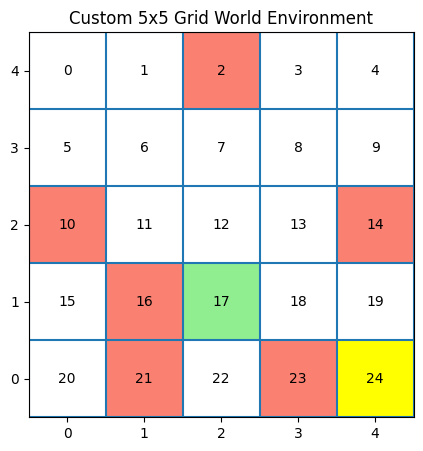

training first 10 episodes...


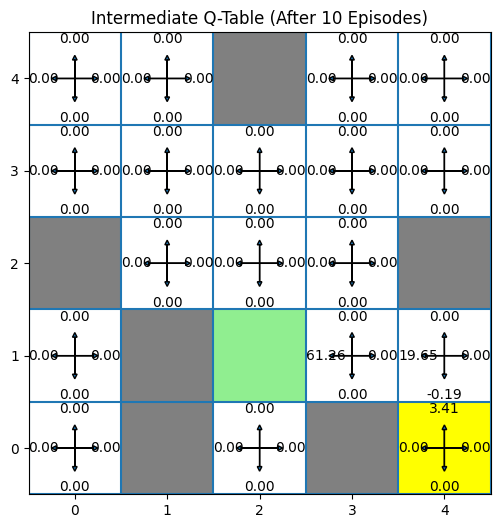

training remaining 290 episodes...


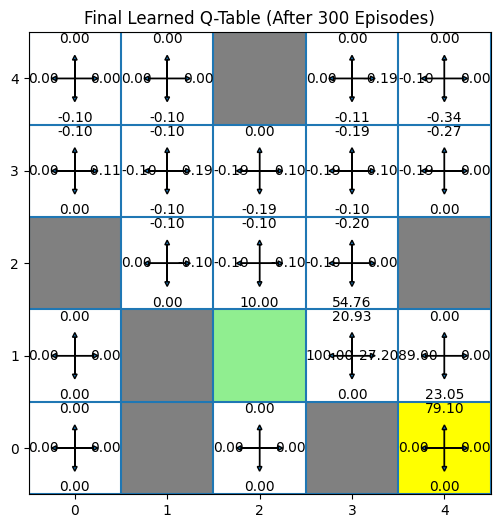

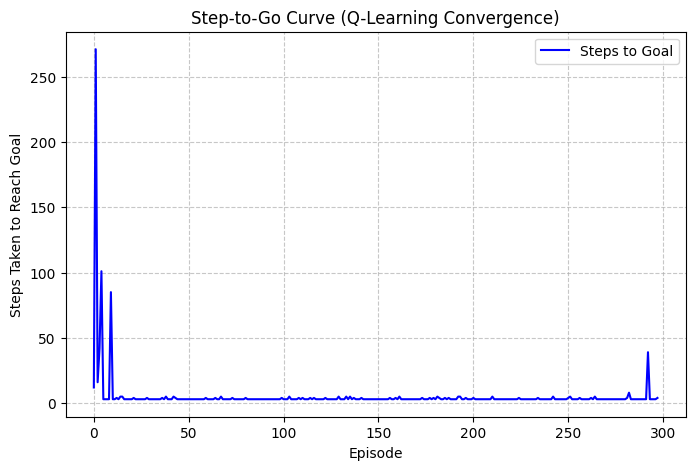

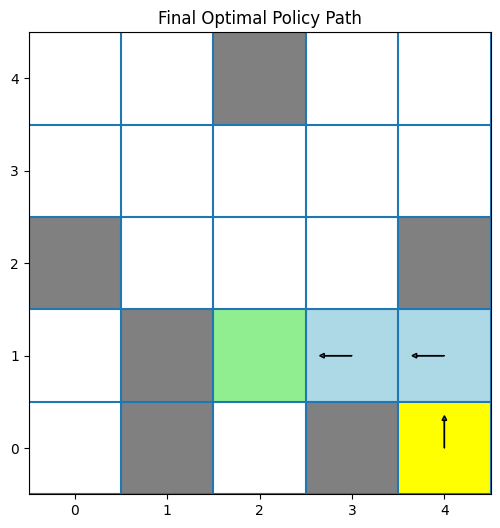

In [6]:
# 1. init an environment larger than 4x3 (5x5)
agent = Agent(
    nrow_maze=5,
    ncol_maze=5,
    seed=42, # fixed seed so the walls stay in the same spot
    rewards={'step': -1, 'wall': -10, 'goal': 100},
    gamma=0.9,
    alpha=0.1,
    epsilon=0.1
)

# 2. create the maze with walls (maze_density dictates the number of obstacles)
agent.init_maze(maze_density=6)

# 3. plot the initial maze
plot_matrix(
    agent.S,
    goal_coords=agent.goal_coords,
    hole_coords=agent.wall_coords,
    start_coords=agent.start_coords,
    title="Custom 5x5 Grid World Environment"
)

# 4. train for a few episodes and show the intermediate q-table
print("training first 10 episodes...")
agent.train_episodes(10)

plot_Q_Table(
    S=agent.S,
    Q=agent.Q,
    goal_coords=agent.goal_coords,
    wall_coords=agent.wall_coords,
    start_coords=agent.start_coords,
    title="Intermediate Q-Table (After 10 Episodes)"
)

# 5. train the remaining episodes to reach convergence
print("training remaining 290 episodes...")
agent.train_episodes(290)

# 6. show the final learned q-table
plot_Q_Table(
    S=agent.S,
    Q=agent.Q,
    goal_coords=agent.goal_coords,
    wall_coords=agent.wall_coords,
    start_coords=agent.start_coords,
    title="Final Learned Q-Table (After 300 Episodes)"
)

# 7. plot the step-to-go curve
plt.figure(figsize=(8, 5))
plt.plot(agent.list_steps_to_goals, label="Steps to Goal", color="blue", linewidth=1.5)
plt.title("Step-to-Go Curve (Q-Learning Convergence)")
plt.xlabel("Episode")
plt.ylabel("Steps Taken to Reach Goal")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 8. plot the final optimal policy path visually
agent.create_policy()
agent.create_optimal_policy_path()
plot_policy(
    S=agent.S,
    policy=agent.policy,
    goal_coords=agent.goal_coords,
    wall_coords=agent.wall_coords,
    start_coords=agent.start_coords,
    optimal_policy_path=agent.optimal_policy_path_coords,
    title="Final Optimal Policy Path"
)

###quick results & analysis
looking at the step-to-go curve, the agent starts off taking a bunch of extra steps (sometimes over 50!) while it randomly explores the grid. but as it trains over the 300 episodes, the curve drops way down and hovers around 3-5 steps for most of the later episodes.

since our absolute shortest path to the goal (start -> up 1 -> left 2) is exactly 3 steps, this means the q-learning algorithm got pretty dang close to the optimal route while avoiding those -10 penalty walls. the final q-table also shows that the highest values point toward the goal path, even if some of the visualizations got a bit messy with all the arrows.

if i ran this for more episodes or tweaked the learning rate, it'd probably lock in at exactly 3 steps every time. but honestly, hovering around 3-4 steps for the last 100 episodes tells me the agent definitely learned what it was supposed to.